**2. MOCO TRAINING**

In [4]:
import digitalhub as dh
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_NAME = "floods"
project = dh.get_project(PROJECT_NAME)
print(f"Project: {project.name}")

Project: floods


**SETUP PARAMETERS**

In [5]:
job_name = "tanh_v1"                                     
dataset = "Standard"                                                                       
weights_encoder_sar = "autoencoder_2D_SAR_weights_convLstm_v1"     
weights_encoder_opt = "autoencoder_2D_OPT_weights_convLstm_v1"
                                        

parameters = {
    "job_name": job_name,
    "dataset": dataset,
    "weights_encoder_sar": weights_encoder_sar,
    "weights_encoder_opt": weights_encoder_opt,
    "resume": False, 
    "lr_min": 0.0003,   
    "cosine": False,  
    "simple_proj": False,
    "pool_grid": 4,
    "attn": False,
    "time_debug": False,   

    "epochs": 40, 
    "batch_size": 16,
    "lr": 0.005,
    "weight_decay": 1e-4,
    "momentum": 0.9,
    "patch_size": 256,
    "n_images1": 4, "n_channels1": 2,              
    "n_images2": 4, "n_channels2": 10,              
    "moco_dim": 128,
    "moco_k": 4096,                                     
    "moco_t": 0.07,
    "hidden_channels_dim": 64,
    "symmetric": False,
    "workers": 0,
    "patience": 40,
    "min_delta": 1e-4,                                   
}

volumes = [
    {
        "volume_type": "ephemeral",
        "name": "volume-spazio-dati",
        "mount_path": "/data",      
        "spec": {"size": "500Gi"}   
    }
]

**BUILD ENVIRONMENT**

In [6]:
moco_2D_train_func = project.new_function(
    name= f'moco_2D_{job_name}',
    kind="python",
    python_version="PYTHON3_10",
    code_src="../src/", 
    handler="train_moco_2D", 
    base_image="pytorch/pytorch:2.1.2-cuda11.8-cudnn8-runtime",
    requirements=["pandas==2.3.3", "numpy==1.26.4", "rasterio==1.4.4", "tqdm==4.70.0", "tifffile==2024.8.30", "torch==2.1.2", "matplotlib==3.10.9", "digitalhub==0.15.11", "digitalhub-runtime-python==0.15.2", "zarr==2.18.0", "numcodecs==0.13.1", "xarray==2025.6.1"]
)

build = moco_2D_train_func.run("build", wait=True)
print(f"BUILD: {build.status.state}")

2026-10-01 20:04:41,067 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run e6f869604570488a84d4547380e7fc6b to finish...
2026-10-01 20:04:46,074 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run e6f869604570488a84d4547380e7fc6b to finish...
2026-10-01 20:04:51,082 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run e6f869604570488a84d4547380e7fc6b to finish...
2026-10-01 20:04:56,089 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run e6f869604570488a84d4547380e7fc6b to finish...
2026-10-01 20:05:01,205 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run e6f869604570488a84d4547380e7fc6b to finish...
2026-10-01 20:05:06,317 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run e6f869604570488a84d4547380e7fc6b to finish...
2026-10-01 20:05:11,325 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run e6f869604570488a84d4547380e7fc6b to finish...
2026-10-01 20

BUILD: COMPLETED


**TRAINING**

In [7]:
run_moco_2D = moco_2D_train_func.run(
    action="job", 
    parameters=parameters, 
    volumes=volumes, 
    profile="1xv100-shared",
    local_execution= False,                       
    wait=True
)

print(f"Run moco avviato: {run_moco_2D.id}")

2026-10-01 20:05:26,643 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 19546ad1bb5e4cb6a582d75f30eb2c0e to finish...
2026-10-01 20:05:31,649 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 19546ad1bb5e4cb6a582d75f30eb2c0e to finish...
2026-10-01 20:05:36,663 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 19546ad1bb5e4cb6a582d75f30eb2c0e to finish...
2026-10-01 20:05:41,671 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 19546ad1bb5e4cb6a582d75f30eb2c0e to finish...
2026-10-01 20:05:46,679 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 19546ad1bb5e4cb6a582d75f30eb2c0e to finish...
2026-10-01 20:05:51,792 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 19546ad1bb5e4cb6a582d75f30eb2c0e to finish...
2026-10-01 20:05:56,800 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run 19546ad1bb5e4cb6a582d75f30eb2c0e to finish...
2026-10-01 20

BackendError: Not found. Response: {"status":404,"message":"No such run.","errorCode":null}.

**PLOTS**

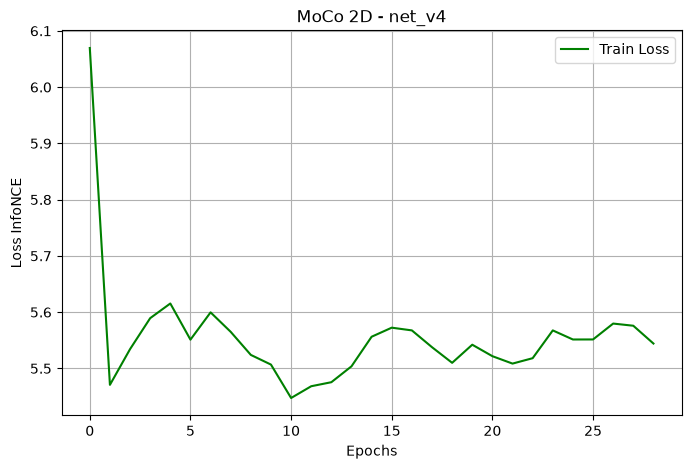

In [ ]:
path = project.get_artifact(f"moco_2D_metrics_{job_name}").download(overwrite=True)
df = pd.read_csv(path)

plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train_loss'], color='green', label='Train Loss')
plt.title(f'MoCo 2D - {job_name}')
plt.xlabel('Epochs')
plt.ylabel('Loss InfoNCE')
plt.grid(True)
plt.legend()
plt.show()